# Matrix Applications

Notebook ini merangkum Chapter 7 dari *Practical Linear Algebra for Data Science*. Chapter ini membahas beberapa aplikasi matrix dalam data science, yaitu **covariance/correlation matrix**, **geometric transformations**, dan **image feature detection**.

Pembahasan dibuat ringkas seperti Chapter 3: fokus pada isi chapter, rumus yang relevan, kode inti, dan kesimpulan.

## Tujuan Pembelajaran

- Memahami covariance matrix untuk data multivariate.
- Menghitung covariance matrix menggunakan matrix multiplication.
- Mengubah covariance matrix menjadi correlation matrix.
- Memahami matrix-vector multiplication sebagai geometric transformation.
- Membuat rotation matrix 2D.
- Memahami konsep pure dan impure transformation.
- Memahami image filtering sebagai perluasan dari time series filtering.
- Membuat Gaussian kernel untuk smoothing.
- Menggunakan 2D convolution untuk feature detection.

## Ringkasan Chapter

Chapter ini menunjukkan bahwa metode penting dalam data science dan machine learning tetap dibangun dari prinsip linear algebra sederhana, terutama dot product, matrix multiplication, dan linear transformations.

Bagian pertama membahas covariance dan correlation matrices. Jika correlation pada dua variable dapat dihitung melalui dot product dua vector yang sudah di-mean-center, maka covariance matrix memperluas ide tersebut ke banyak variable sekaligus menggunakan matrix multiplication.

Bagian kedua membahas geometric transformation. Matrix-vector multiplication digunakan untuk mengubah koordinat titik, misalnya melakukan rotasi atau stretching. Chapter ini memperkenalkan pure rotation matrix yang memutar titik tanpa mengubah panjangnya.

Bagian ketiga membahas image feature detection. Image filtering dipahami sebagai versi 2D dari time series filtering. Kernel kecil digeser pada image, lalu setiap output dihitung melalui Hadamard multiplication dan penjumlahan elemen. Contohnya adalah Gaussian smoothing dan kernel deteksi garis horizontal/vertikal.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| Multivariate Data Covariance Matrices | Covariance matrix dihitung dari data matrix yang sudah di-mean-center. |
| Correlation Matrix | Correlation matrix diperoleh dengan menormalisasi covariance matrix. |
| Geometric Transformations | Matrix multiplication digunakan untuk transformasi koordinat. |
| Pure Rotation Matrix | Matrix rotasi memutar titik tanpa mengubah panjang vector. |
| Wobbly Circle | Animasi transformasi matrix pada titik-titik lingkaran. |
| Image Feature Detection | Kernel 2D digunakan untuk smoothing dan feature detection pada image. |

## Persiapan Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.signal import convolve2d
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

np.random.seed(2024)

## Multivariate Data Covariance Matrices

Pada Chapter 4, Pearson correlation dihitung untuk dua variable menggunakan dot product antara dua variable yang sudah di-mean-center. Chapter ini memperluas ide tersebut untuk banyak variable sekaligus.

Covariance menunjukkan hubungan linear antara dua variable, tetapi berbeda dari correlation karena tidak dibatasi pada rentang $-1$ sampai $+1$. Covariance tetap mempertahankan skala data asli.

## Rumus Covariance Dua Variable

Covariance antara dua variable $x$ dan $y$ ditulis sebagai:

$$
c_{x,y}
=
\frac{1}{n-1}
\sum_{i=1}^{n}
(x_i-\bar{x})(y_i-\bar{y})
$$

Keterangan:

- $c_{x,y}$ = covariance antara variable $x$ dan $y$
- $x_i$ = data ke-$i$ pada variable $x$
- $y_i$ = data ke-$i$ pada variable $y$
- $\bar{x}$ = rata-rata variable $x$
- $\bar{y}$ = rata-rata variable $y$
- $n$ = jumlah data

Jika $x$ dan $y$ sudah di-mean-center, covariance dapat dipahami sebagai dot product yang dibagi dengan $n-1$.

## Rumus Covariance Matrix

Untuk data matrix $X$ yang setiap column-nya adalah variable dan sudah di-mean-center, covariance matrix dapat dihitung dengan:

$$
C =
\frac{X^TX}{n-1}
$$

Keterangan:

- $C$ = covariance matrix
- $X$ = data matrix yang sudah di-mean-center
- $X^T$ = transpose dari data matrix
- $n$ = jumlah observasi

Hasil covariance matrix selalu berbentuk **features-by-features**, sehingga matrix ini berbentuk square dan symmetric.

In [2]:
# Membuat data multivariate sederhana: 200 observasi, 5 fitur
n = 200
dataMat = np.random.randn(n, 5)

# Tambahkan sedikit hubungan antar fitur agar covariance terlihat
dataMat[:, 1] = dataMat[:, 0] * 0.6 + np.random.randn(n) * 0.4
dataMat[:, 2] = -dataMat[:, 0] * 0.5 + np.random.randn(n) * 0.6

datamean = np.mean(dataMat, axis=0)
dataMatM = dataMat - datamean

covMat = dataMatM.T @ dataMatM
covMat = covMat / (dataMatM.shape[0] - 1)

print("Covariance matrix:")
print(np.round(covMat, 3))
print("\nShape:", covMat.shape)
print("Symmetric?", np.allclose(covMat, covMat.T))

Covariance matrix:
[[ 0.958  0.554 -0.553 -0.051 -0.123]
 [ 0.554  0.459 -0.283 -0.008 -0.051]
 [-0.553 -0.283  0.719  0.04   0.067]
 [-0.051 -0.008  0.04   1.065  0.041]
 [-0.123 -0.051  0.067  0.041  1.071]]

Shape: (5, 5)
Symmetric? True


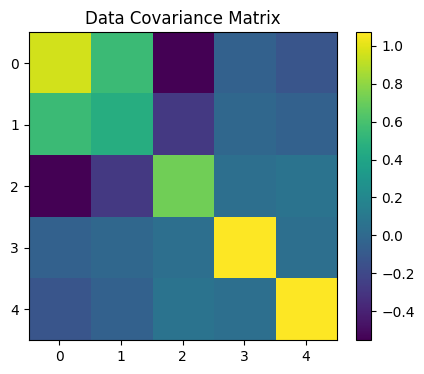

In [3]:
plt.figure(figsize=(5, 4))
plt.imshow(covMat)
plt.colorbar()
plt.title("Data Covariance Matrix")
plt.show()

## Interpretasi Covariance Matrix

Elemen diagonal covariance matrix berisi covariance variable dengan dirinya sendiri. Dalam statistik, nilai ini disebut **variance**. Elemen di luar diagonal menunjukkan covariance antar pasangan variable.

Karena covariance antara fitur $i$ dan fitur $j$ sama dengan covariance antara fitur $j$ dan fitur $i$, covariance matrix bersifat symmetric.

## Correlation Matrix dari Covariance Matrix

Chapter ini menjelaskan bahwa correlation matrix dapat diperoleh dari covariance matrix dengan melakukan scaling berdasarkan standard deviation setiap variable.

### Rumus Correlation dari Covariance

$$
R = SCS
$$

Keterangan:

- $R$ = correlation matrix
- $C$ = covariance matrix
- $S$ = diagonal matrix berisi reciprocal standard deviation
- Elemen diagonal $S$ adalah $\frac{1}{\sigma_i}$
- $\sigma_i$ = standard deviation variable ke-$i$

Pre-multiplication dan post-multiplication dengan $S$ menormalisasi covariance sehingga menjadi correlation.

In [4]:
stds = np.sqrt(np.diag(covMat))
S = np.diag(1 / stds)

corrMat = S @ covMat @ S

print("Correlation matrix:")
print(np.round(corrMat, 3))

print("\nDiagonal correlation:")
print(np.round(np.diag(corrMat), 3))

Correlation matrix:
[[ 1.     0.834 -0.666 -0.05  -0.122]
 [ 0.834  1.    -0.493 -0.012 -0.073]
 [-0.666 -0.493  1.     0.046  0.076]
 [-0.05  -0.012  0.046  1.     0.039]
 [-0.122 -0.073  0.076  0.039  1.   ]]

Diagonal correlation:
[1. 1. 1. 1. 1.]


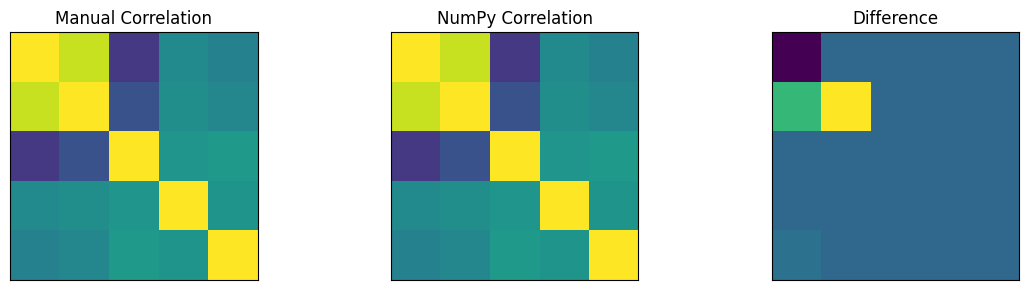

Manual and NumPy correlation equal? True


In [5]:
corr_np = np.corrcoef(dataMat, rowvar=False)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].imshow(corrMat, vmin=-1, vmax=1)
axes[0].set_title("Manual Correlation")

axes[1].imshow(corr_np, vmin=-1, vmax=1)
axes[1].set_title("NumPy Correlation")

axes[2].imshow(corrMat - corr_np)
axes[2].set_title("Difference")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

print("Manual and NumPy correlation equal?", np.allclose(corrMat, corr_np))

## Geometric Transformations via Matrix-Vector Multiplication

Chapter ini menjelaskan bahwa salah satu fungsi matrix-vector multiplication adalah menerapkan geometric transform pada koordinat.

Jika titik-titik koordinat disimpan dalam matrix $2 \times N$, maka transformation matrix $2 \times 2$ dapat dikalikan dengan matrix titik tersebut untuk menghasilkan titik yang sudah ditransformasi.

## Rumus Pure Rotation Matrix

Pure rotation matrix 2D untuk rotasi searah jarum jam ditulis sebagai:

$$
T =
\begin{bmatrix}
\cos(\theta) & \sin(\theta) \\
-\sin(\theta) & \cos(\theta)
\end{bmatrix}
$$

Keterangan:

- $T$ = transformation matrix
- $\theta$ = sudut rotasi
- Jika $\theta=0$, maka $T=I$
- Jika $\theta=\frac{\pi}{2}$, titik diputar 90 derajat
- Pure rotation mempertahankan panjang vector

Matrix ini termasuk orthogonal matrix karena columns-nya orthogonal dan merupakan unit vectors.

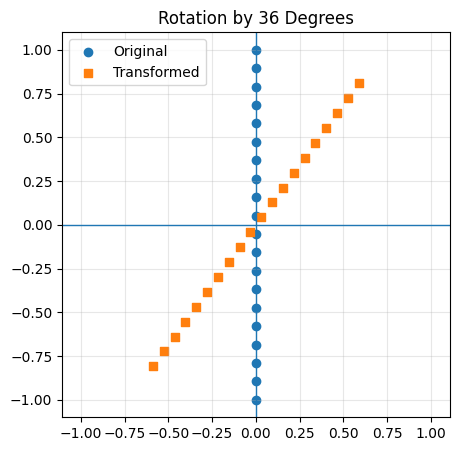

In [6]:
theta = np.pi / 5

T = np.array([
    [np.cos(theta), np.sin(theta)],
    [-np.sin(theta), np.cos(theta)]
])

# Titik-titik pada garis vertikal
x = np.zeros(20)
y = np.linspace(-1, 1, 20)
points = np.vstack((x, y))

transformed = T @ points

plt.figure(figsize=(5, 5))
plt.scatter(points[0, :], points[1, :], label="Original")
plt.scatter(transformed[0, :], transformed[1, :], marker="s", label="Transformed")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.axis("equal")
plt.grid(alpha=0.3)
plt.title("Rotation by 36 Degrees")
plt.legend()
plt.show()

## Pure Rotation dan Orthogonality

Pure rotation matrix tidak mengubah panjang vector. Untuk mengeceknya, kita dapat membandingkan norm titik sebelum dan setelah transformasi.

Jika transformasi benar-benar pure rotation, maka:

$$
\|x\| = \|Tx\|
$$

In [7]:
original_norms = np.linalg.norm(points, axis=0)
transformed_norms = np.linalg.norm(transformed, axis=0)

print("Norms preserved?", np.allclose(original_norms, transformed_norms))

Norms preserved? True


## Impure Transformation: The Wobbly Circle

Chapter juga membahas impure transformation, yaitu transformasi yang tidak hanya memutar, tetapi juga dapat melakukan stretching atau shearing.

Transformation matrix yang digunakan pada contoh *The Wobbly Circle* adalah:

$$
T =
\begin{bmatrix}
1 & 1-\phi \\
0 & 1
\end{bmatrix}
$$

Keterangan:

- $\phi$ berubah dari 1 ke 0 lalu kembali ke 1
- Ketika $\phi=1$, maka $T=I$
- Off-diagonal element menyebabkan bentuk lingkaran berubah menjadi miring atau wobbly

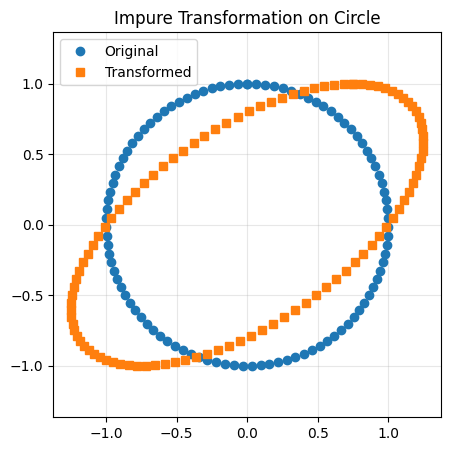

In [8]:
theta = np.linspace(0, 2*np.pi, 100)
points = np.vstack((np.sin(theta), np.cos(theta)))

phi = 0.25
T = np.array([
    [1, 1-phi],
    [0, 1]
])

P = T @ points

plt.figure(figsize=(5, 5))
plt.plot(points[0, :], points[1, :], "o", label="Original")
plt.plot(P[0, :], P[1, :], "s", label="Transformed")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.title("Impure Transformation on Circle")
plt.legend()
plt.show()

## Image Feature Detection

Image filtering adalah perluasan dari time series filtering. Jika time series filtering bekerja pada data 1D, maka image filtering bekerja pada data 2D.

Ide utamanya:

1. Buat kernel 2D.
2. Ambil window kecil dari image dengan ukuran sama seperti kernel.
3. Lakukan Hadamard multiplication antara window dan kernel.
4. Jumlahkan seluruh hasil perkalian.
5. Simpan hasilnya sebagai pixel baru.

Operasi ini merupakan dasar dari image convolution.

## Rumus Operasi Filtering 2D

Untuk satu posisi image, hasil filtering dapat ditulis sebagai:

$$
o =
\sum_{i}
\sum_{j}
I_{ij}K_{ij}
$$

Keterangan:

- $o$ = output pixel hasil filtering
- $I_{ij}$ = elemen image window
- $K_{ij}$ = elemen kernel
- Operasi ini setara dengan Hadamard multiplication lalu penjumlahan semua elemen

## Gaussian Kernel

Chapter memperkenalkan Gaussian kernel 2D untuk smoothing.

### Rumus Gaussian Kernel

$$
G =
\exp
\left(
-\frac{X^2+Y^2}{\sigma}
\right)
$$

Keterangan:

- $G$ = Gaussian kernel
- $X$ dan $Y$ = grid koordinat 2D
- $\sigma$ = width atau shape parameter
- Nilai $\sigma$ kecil membuat kernel lebih sempit
- Nilai $\sigma$ besar membuat kernel lebih lebar

Kernel kemudian dinormalisasi agar jumlah seluruh elemennya sama dengan 1.

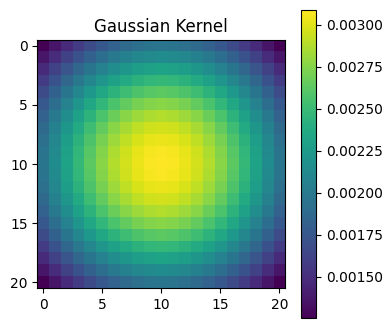

Sum of kernel: 1.0


In [9]:
Y, X = np.meshgrid(
    np.linspace(-3, 3, 21),
    np.linspace(-3, 3, 21)
)

kernel = np.exp(-(X**2 + Y**2) / 20)
kernel = kernel / np.sum(kernel)

plt.figure(figsize=(4, 4))
plt.imshow(kernel)
plt.colorbar()
plt.title("Gaussian Kernel")
plt.show()

print("Sum of kernel:", np.sum(kernel))

## Image Smoothing dengan Convolution

Contoh berikut menggunakan random matrix sebagai image sederhana. Kernel Gaussian digunakan untuk menghasilkan image yang lebih halus.

Implementasi double for loop mengikuti prinsip chapter: ambil potongan image, lakukan Hadamard multiplication dengan kernel, lalu jumlahkan hasilnya.

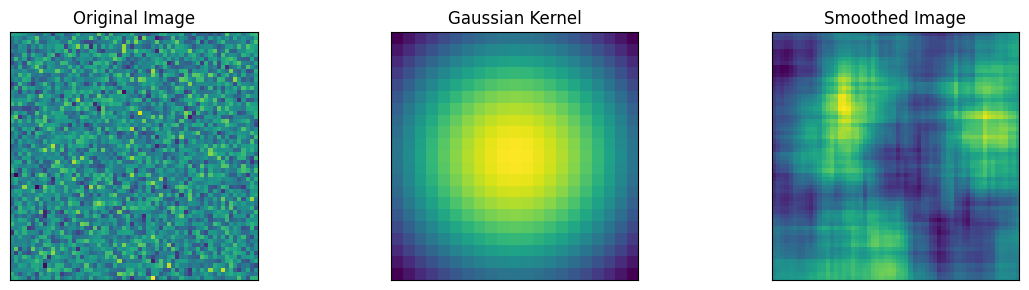

In [10]:
imgN = 60
image = np.random.randn(imgN, imgN)

kernelN = kernel.shape[0]
halfKr = kernelN // 2

imagePad = np.pad(image, halfKr, mode="constant")
convoutput = np.zeros_like(image)

for rowi in range(halfKr, imgN + halfKr):
    for coli in range(halfKr, imgN + halfKr):
        pieceOfImg = imagePad[
            rowi-halfKr:rowi+halfKr+1,
            coli-halfKr:coli+halfKr+1
        ]
        dotprod = np.sum(pieceOfImg * kernel)
        convoutput[rowi-halfKr, coli-halfKr] = dotprod

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].imshow(image)
axes[0].set_title("Original Image")

axes[1].imshow(kernel)
axes[1].set_title("Gaussian Kernel")

axes[2].imshow(convoutput)
axes[2].set_title("Smoothed Image")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Catatan tentang Efisiensi Convolution

Chapter menjelaskan bahwa implementasi convolution dengan double for loop tidak efisien untuk image besar. Convolution dapat dihitung lebih cepat di frequency domain berdasarkan convolution theorem.

Dalam praktik, chapter menyarankan penggunaan fungsi seperti `scipy.signal.convolve2d()` untuk image besar.

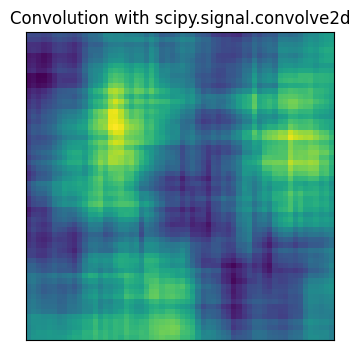

In [11]:
if SCIPY_AVAILABLE:
    conv_scipy = convolve2d(image, kernel, mode="same")

    plt.figure(figsize=(4, 4))
    plt.imshow(conv_scipy)
    plt.title("Convolution with scipy.signal.convolve2d")
    plt.xticks([])
    plt.yticks([])
    plt.show()
else:
    print("SciPy tidak tersedia, contoh convolve2d dilewati.")

## Feature Detection Kernels

Selain smoothing, kernel juga dapat digunakan untuk mendeteksi fitur tertentu. Chapter memberi contoh kernel untuk mendeteksi garis vertikal dan horizontal.

Kernel tersebut berukuran $3 \times 3$ dan berisi nilai $-1$, $0$, dan $+1$.

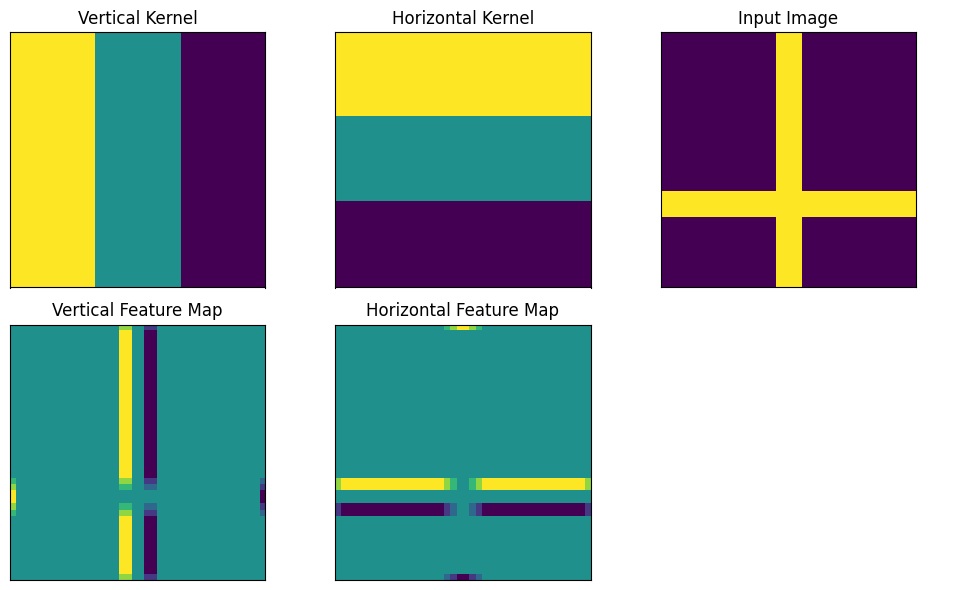

In [12]:
vertical_kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

horizontal_kernel = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
])

# Buat image sederhana dengan garis vertikal dan horizontal
simple_img = np.zeros((40, 40))
simple_img[:, 18:22] = 1
simple_img[25:29, :] = 1

if SCIPY_AVAILABLE:
    vertical_edges = convolve2d(simple_img, vertical_kernel, mode="same")
    horizontal_edges = convolve2d(simple_img, horizontal_kernel, mode="same")
else:
    vertical_edges = simple_img
    horizontal_edges = simple_img

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

axes[0, 0].imshow(vertical_kernel)
axes[0, 0].set_title("Vertical Kernel")
axes[0, 1].imshow(horizontal_kernel)
axes[0, 1].set_title("Horizontal Kernel")
axes[0, 2].imshow(simple_img)
axes[0, 2].set_title("Input Image")

axes[1, 0].imshow(vertical_edges)
axes[1, 0].set_title("Vertical Feature Map")
axes[1, 1].imshow(horizontal_edges)
axes[1, 1].set_title("Horizontal Feature Map")
axes[1, 2].axis("off")

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| Covariance | Hubungan linear antar variable yang tetap mempertahankan skala data. |
| Covariance matrix | Matrix features-by-features berisi covariance antar semua pasangan fitur. |
| Correlation matrix | Covariance matrix yang sudah dinormalisasi standard deviation. |
| Matrix transform | Matrix-vector multiplication untuk mengubah koordinat titik. |
| Pure rotation | Rotasi yang mempertahankan panjang vector. |
| Impure transform | Transformasi yang dapat melibatkan stretching atau shearing. |
| Image filtering | Penerapan kernel 2D pada image untuk smoothing atau feature detection. |
| Gaussian kernel | Kernel smooth berbentuk bell-shaped untuk low-pass filtering. |
| Convolution | Operasi menggeser kernel pada image dan menghitung output lokal. |
| Feature map | Output hasil filtering yang menonjolkan fitur tertentu. |

## Kesimpulan Chapter

Chapter ini memperlihatkan bahwa konsep matrix dari chapter sebelumnya memiliki aplikasi langsung dalam data science. Covariance dan correlation matrix menggunakan matrix multiplication untuk menghitung hubungan antar banyak variable secara ringkas tanpa loop manual.

Matrix-vector multiplication juga digunakan sebagai alat geometric transformation. Dengan transformation matrix, titik-titik koordinat dapat diputar, diskalakan, atau diubah bentuknya. Pure rotation matrix mempertahankan panjang vector, sedangkan impure transformation dapat mengubah bentuk objek.

Pada bagian image feature detection, chapter menunjukkan bahwa image filtering adalah perluasan dari time series filtering ke data 2D. Kernel digunakan untuk smoothing atau mendeteksi fitur seperti garis horizontal dan vertikal. Secara keseluruhan, chapter ini menekankan bahwa metode yang terlihat kompleks dalam data science dan machine learning tetap dibangun dari prinsip linear algebra sederhana seperti dot product, Hadamard multiplication, dan matrix multiplication.